# Análisis de resultados — Oscilador Armónico Clásico

Este notebook analiza los resultados del estudio de sensibilidad sobre la PINN 
aplicada al oscilador armónico clásico. Se estudian los siguientes ejes:

1. **Puntos de colocación**: 50, 100, 250, 500 (base), 1000
2. **Sampler**: LHS (base) vs. grid
3. **Optimizador**: Adam (base) vs. Adam+L-BFGS
4. **Arquitectura**: [32,32,32] (base) vs. [64,64,64]
5. **Pesos dinámicos**: desactivados (base) vs. activados
6. **Learning rate**: 0.001 (base) vs. 0.01
7. **Puntos de entrenamiento**: 3, 5, 10, 15 (base), 30
8. **Región de entrenamiento**: 20% (base) vs. 50%
9. **Cruce puntos × región**: combinaciones con región 50%

Cada configuración se ejecuta con 10 seeds distintas. 
La referencia numérica es RK4.

In [17]:
import json
import os
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib as mpl
import seaborn as sns
from scipy import stats

mpl.rcParams.update({
    "font.family":        "serif",
    "font.size":          12,
    "axes.linewidth":     1.2,
    "xtick.direction":    "in",
    "ytick.direction":    "in",
    "xtick.minor.visible": True,
    "ytick.minor.visible": True,
    "figure.dpi":         150,
})

RESULTS_DIR = Path("results")
FIGS_DIR    = Path("figures_analysis")
FIGS_DIR.mkdir(exist_ok=True)

In [18]:
records = []

for fpath in sorted(RESULTS_DIR.glob("oscilador_clasico/**/*.json")):
    with open(fpath) as f:
        d = json.load(f)
    
    cfg = d["config"]
    res = d["resultados_finales"]
    
    records.append({
        # ── Configuración ──────────────────────────────────────────
        "seed":                cfg["seed"],
        "epochs":              cfg["epochs"],
        "lr":                  cfg["lr"],
        "num_domain_points":   cfg["num_domain_points"],
        "num_train_points":    cfg["num_train_points"],
        "train_region":        cfg["train_region"],
        "sampler":             cfg["sampler"],
        "use_dynamic_weights": cfg["use_dynamic_weights"],
        "optimizer":           cfg["optimizer"],
        "hidden_layers":       str(cfg["hidden_layers"]),
        # ── Resultados PINN ────────────────────────────────────────
        "error_l2_pinn":       res["pinn"]["error_L2"],
        "time_pinn":           res["pinn"]["time_s"],
        # ── Resultados NN pura ─────────────────────────────────────
        "error_l2_nn":         res["nn"]["error_L2"],
        "time_nn":             res["nn"]["time_s"],
        # ── Resultados RK4 ─────────────────────────────────────────
        "error_l2_rk4":        res["rk4"]["error_L2"],
        "time_rk4":            res["rk4"]["time_s"],
    })

df = pd.DataFrame(records)
print(f"Total de experimentos cargados: {len(df)}")
df.head()

Total de experimentos cargados: 190


,seed,epochs,lr,num_domain_points,num_train_points,train_region,sampler,use_dynamic_weights,optimizer,hidden_layers,error_l2_pinn,time_pinn,error_l2_nn,time_nn,error_l2_rk4,time_rk4
0,42,10000,0.001,500,15,0.2,grid,False,adam,"[32, 32, 32]",0.006610,31.865522,1.840128,7.507957,3.131327e-07,0.001998
1,123,10000,0.001,500,15,0.2,grid,False,adam,"[32, 32, 32]",0.613544,32.013007,1.713792,7.429007,3.131327e-07,0.001998
2,7,10000,0.001,500,15,0.2,grid,False,adam,"[32, 32, 32]",0.057267,32.409029,1.722050,7.845742,3.131327e-07,0.001003
3,99,10000,0.001,500,15,0.2,grid,False,adam,"[32, 32, 32]",0.152183,31.783359,1.786867,7.496450,3.131327e-07,0.002007
4,2024,10000,0.001,500,15,0.2,grid,False,adam,"[32, 32, 32]",0.283203,32.004876,1.713744,7.494350,3.131327e-07,0.001001


In [22]:
BASE = {
    "num_domain_points":   500,
    "num_train_points":    15,
    "train_region":        0.2,
    "sampler":             "lhs",
    "use_dynamic_weights": False,
    "optimizer":           "adam",
    "hidden_layers":       "[32, 32, 32]",
    "lr":                  0.001,
}

def is_base(row):
    return all(row[k] == v for k, v in BASE.items())

df["is_base"] = df.apply(is_base, axis=1)

df_base = df[df["is_base"]]
print(f"Experimentos BASE: {len(df_base)} (esperados: 10)")

print(f"\nError L2 PINN base — media: {df_base['error_l2_pinn'].mean():.4e} "
      f"± {df_base['error_l2_pinn'].std():.4e}")
print(f"Error L2 NN   base — media: {df_base['error_l2_nn'].mean():.4e} "
      f"± {df_base['error_l2_nn'].std():.4e}")
print(f"Error L2 RK4  base — media: {df_base['error_l2_rk4'].mean():.4e} "
      f"± {df_base['error_l2_rk4'].std():.4e}")

print(f"\nTiempo PINN base   — media: {df_base['time_pinn'].mean():.2f}s "
      f"± {df_base['time_pinn'].std():.2f}s")
print(f"Tiempo NN   base   — media: {df_base['time_nn'].mean():.2f}s "
      f"± {df_base['time_nn'].std():.2f}s")
print(f"Tiempo RK4  base   — media: {df_base['time_rk4'].mean():.4f}s")

Experimentos BASE: 10 (esperados: 10)

Error L2 PINN base — media: 1.8111e-01 ± 2.4130e-01
Error L2 NN   base — media: 1.7228e+00 ± 7.2427e-02
Error L2 RK4  base — media: 3.1313e-07 ± 0.0000e+00

Tiempo PINN base   — media: 32.36s ± 0.95s
Tiempo NN   base   — media: 7.60s ± 0.27s
Tiempo RK4  base   — media: 0.0013s


## Eje 1: Número de puntos de colocación

Se varía el número de puntos de colocación entre 50 y 1000, 
manteniendo el resto de parámetros en su valor base.
Se analiza el impacto sobre el error L2 final de la PINN.

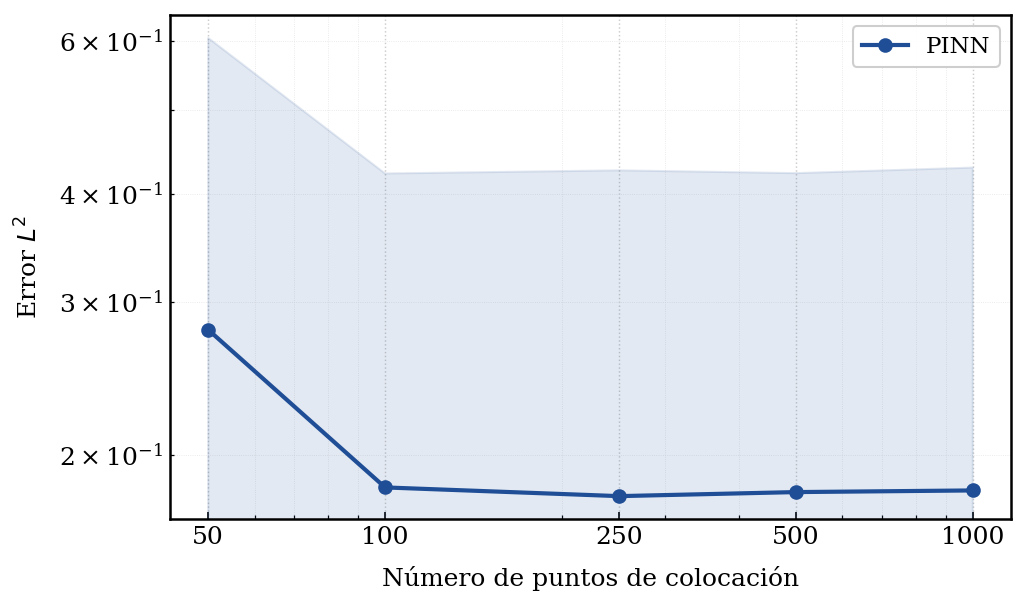

NN pura (base): media=1.7228e+00 ± std=7.2427e-02
RK4 (base):     media=3.1313e-07

PINN por puntos de colocación:
num_domain_points error_l2_pinn          error_l2_nn         
                           mean      std        mean      std
               50      0.278717 0.326210    1.722828 0.072427
              100      0.183365 0.238668    1.722828 0.072427
              250      0.179175 0.246395    1.722828 0.072427
              500      0.181111 0.241304    1.722828 0.072427
             1000      0.181906 0.246781    1.722828 0.072427


In [24]:
configs_eje1 = [50, 100, 250, 500, 1000]

mask_eje1 = (
    df["num_domain_points"].isin(configs_eje1) &
    (df["num_train_points"]    == BASE["num_train_points"]) &
    (df["train_region"]        == BASE["train_region"]) &
    (df["sampler"]             == BASE["sampler"]) &
    (df["use_dynamic_weights"] == BASE["use_dynamic_weights"]) &
    (df["optimizer"]           == BASE["optimizer"]) &
    (df["hidden_layers"]       == BASE["hidden_layers"]) &
    (df["lr"]                  == BASE["lr"])
)

df_eje1 = df[mask_eje1].groupby("num_domain_points")[
    ["error_l2_pinn", "error_l2_nn"]
].agg(["mean", "std"]).reset_index()

# ── Colores ────────────────────────────────────────────────────────────────
C_PINN = "#1f4e96"
C_NN   = "#e07b39"
C_RK4  = "#888888"

fig, ax = plt.subplots(figsize=(7, 4.2))

x     = df_eje1["num_domain_points"].values
y_p   = df_eje1["error_l2_pinn"]["mean"].values
s_p   = df_eje1["error_l2_pinn"]["std"].values
y_nn  = df_base["error_l2_nn"].mean()
s_nn  = df_base["error_l2_nn"].std()
y_rk4 = df_base["error_l2_rk4"].mean()

# PINN: línea + área sombreada ±1σ
ax.plot(x, y_p, "o-", color=C_PINN, linewidth=2, markersize=6,
        zorder=3, label="PINN")
ax.fill_between(x, y_p - s_p, y_p + s_p,
                color=C_PINN, alpha=0.12, zorder=2)

# ── Ejes ───────────────────────────────────────────────────────────────────
ax.set_xlabel("Número de puntos de colocación", labelpad=8)
ax.set_ylabel("Error $L^2$", labelpad=8)
ax.set_xscale("log")
ax.set_yscale("log")
ax.set_xticks(configs_eje1)
ax.get_xaxis().set_major_formatter(mpl.ticker.ScalarFormatter())

# ── Grid y leyenda ─────────────────────────────────────────────────────────
ax.grid(True, which="major", linestyle=":", linewidth=0.7,
        color="#cccccc", zorder=0)
ax.grid(True, which="minor", linestyle=":", linewidth=0.4,
        color="#e5e5e5", zorder=0)

legend = ax.legend(
    frameon=True, framealpha=0.95, edgecolor="#cccccc",
    fontsize=11, loc="upper right"
)

plt.tight_layout()
plt.savefig(FIGS_DIR / "eje1_colocation_points.png", dpi=300, bbox_inches="tight")
plt.show()

print(f"NN pura (base): media={y_nn:.4e} ± std={s_nn:.4e}")
print(f"RK4 (base):     media={y_rk4:.4e}")
print("\nPINN por puntos de colocación:")
print(df_eje1.to_string(index=False))

## Eje 2: Estrategia de muestreo

Se compara LHS (base) frente a malla uniforme (grid), 
manteniendo el resto de parámetros en su valor base.

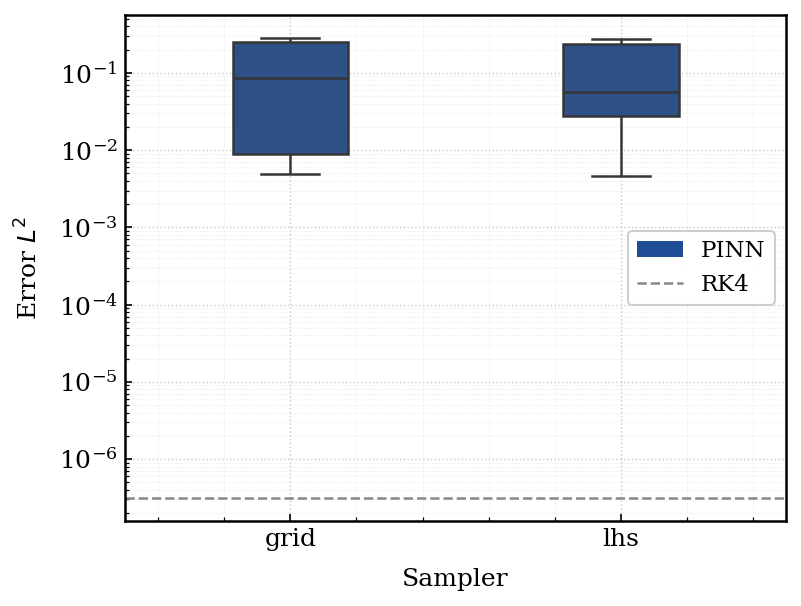

grid: PINN=1.8670e-01 ± 2.4244e-01
lhs: PINN=1.8111e-01 ± 2.4130e-01
NN pura:  1.7228e+00 ± 7.2427e-02
RK4:      3.1313e-07


In [30]:
mask_eje2 = (
    df["sampler"].isin(["lhs", "grid"]) &
    (df["num_domain_points"]   == BASE["num_domain_points"]) &
    (df["num_train_points"]    == BASE["num_train_points"]) &
    (df["train_region"]        == BASE["train_region"]) &
    (df["use_dynamic_weights"] == BASE["use_dynamic_weights"]) &
    (df["optimizer"]           == BASE["optimizer"]) &
    (df["hidden_layers"]       == BASE["hidden_layers"]) &
    (df["lr"]                  == BASE["lr"])
)

df_eje2_pinn = df[mask_eje2][["sampler", "error_l2_pinn"]].copy()

fig, ax = plt.subplots(figsize=(5.5, 4.2))

sns.boxplot(
    data=df_eje2_pinn, x="sampler", y="error_l2_pinn",
    color="#1f4e96", width=0.35, linewidth=1.2,
    showfliers=False, ax=ax
)

ax.axhline(
    df_base["error_l2_rk4"].mean(),
    color="#888888", linewidth=1.2, linestyle="--",
    zorder=2, label="RK4"
)

# Parche manual para PINN en leyenda
from matplotlib.patches import Patch
handles, labels = ax.get_legend_handles_labels()
pinn_patch = Patch(facecolor="#1f4e96", label="PINN")
ax.legend(handles=[pinn_patch] + handles, frameon=True,
          framealpha=0.95, edgecolor="#cccccc", fontsize=11)

ax.set_xlabel("Sampler", labelpad=8)
ax.set_ylabel("Error $L^2$", labelpad=8)
ax.set_yscale("log")
ax.grid(True, which="major", linestyle=":", linewidth=0.7, color="#cccccc", zorder=0)
ax.grid(True, which="minor", linestyle=":", linewidth=0.4, color="#e5e5e5", zorder=0)

plt.tight_layout()
plt.savefig(FIGS_DIR / "eje2_sampler.png", dpi=300, bbox_inches="tight")
plt.show()

for sampler, grp in df[mask_eje2].groupby("sampler"):
    print(f"{sampler}: PINN={grp['error_l2_pinn'].mean():.4e} ± {grp['error_l2_pinn'].std():.4e}")
print(f"NN pura:  {df_base['error_l2_nn'].mean():.4e} ± {df_base['error_l2_nn'].std():.4e}")
print(f"RK4:      {df_base['error_l2_rk4'].mean():.4e}")

## Eje 3: Optimizador

Se compara Adam (base) frente a Adam+L-BFGS, 
manteniendo el resto de parámetros en su valor base.

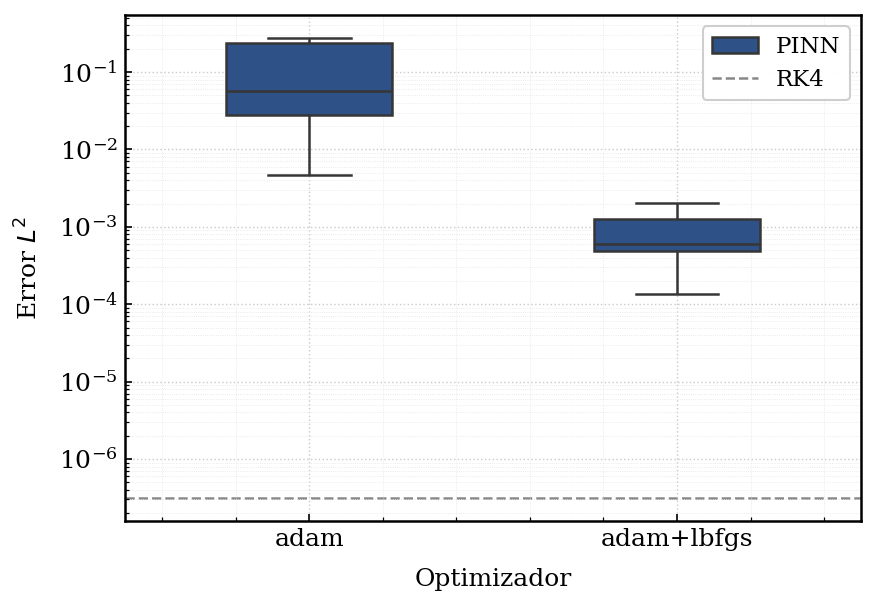

adam: PINN=1.8111e-01 ± 2.4130e-01 
adam+lbfgs: PINN=1.0619e-03 ± 1.0651e-03 
RK4: 3.1313e-07


In [35]:
mask_eje3 = (
    df["optimizer"].isin(["adam", "adam+lbfgs"]) &
    (df["num_domain_points"]   == BASE["num_domain_points"]) &
    (df["num_train_points"]    == BASE["num_train_points"]) &
    (df["train_region"]        == BASE["train_region"]) &
    (df["sampler"]             == BASE["sampler"]) &
    (df["use_dynamic_weights"] == BASE["use_dynamic_weights"]) &
    (df["hidden_layers"]       == BASE["hidden_layers"]) &
    (df["lr"]                  == BASE["lr"])
)

df_eje3_long = df[mask_eje3].melt(
    id_vars=["optimizer"],
    value_vars=["error_l2_pinn"],
    var_name="modelo", value_name="error_l2"
).replace({"error_l2_pinn": "PINN"})

fig, ax = plt.subplots(figsize=(6, 4.2))

sns.boxplot(
    data=df_eje3_long, x="optimizer", y="error_l2", hue="modelo",
    palette={"PINN": "#1f4e96"},
    width=0.45, linewidth=1.2, showfliers=False, ax=ax
)
ax.axhline(
    df_base["error_l2_rk4"].mean(),
    color="#888888", linewidth=1.2, linestyle="--", zorder=0, label="RK4"
)
handles, labels = ax.get_legend_handles_labels()
ax.legend(handles, labels, frameon=True, framealpha=0.95,
          edgecolor="#cccccc", fontsize=11, title=None)

ax.set_xlabel("Optimizador", labelpad=8)
ax.set_ylabel("Error $L^2$", labelpad=8)
ax.set_yscale("log")
ax.grid(True, which="major", linestyle=":", linewidth=0.7, color="#cccccc", zorder=0)
ax.grid(True, which="minor", linestyle=":", linewidth=0.4, color="#e5e5e5", zorder=0)

plt.tight_layout()
plt.savefig(FIGS_DIR / "eje3_optimizer_box.png", dpi=300, bbox_inches="tight")
plt.show()

for opt, grp in df[mask_eje3].groupby("optimizer"):
    print(f"{opt}: PINN={grp['error_l2_pinn'].mean():.4e} ± {grp['error_l2_pinn'].std():.4e} ")
print(f"RK4: {df_base['error_l2_rk4'].mean():.4e}")

## Eje 4: Arquitectura de la red

Se compara la arquitectura base [32,32,32] frente a [64,64,64],
manteniendo el resto de parámetros en su valor base.

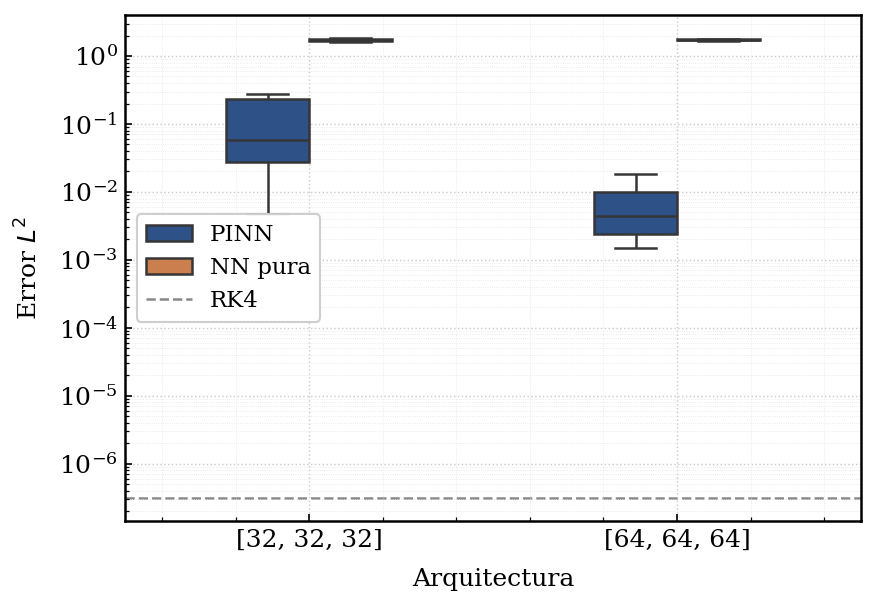

[32, 32, 32]: PINN=1.8111e-01 ± 2.4130e-01 | NN=1.7228e+00 ± 7.2427e-02
[64, 64, 64]: PINN=7.7053e-03 ± 7.4038e-03 | NN=1.7430e+00 ± 3.5401e-02
RK4: 3.1313e-07


In [36]:
mask_eje4 = (
    df["hidden_layers"].isin(["[32, 32, 32]", "[64, 64, 64]"]) &
    (df["num_domain_points"]   == BASE["num_domain_points"]) &
    (df["num_train_points"]    == BASE["num_train_points"]) &
    (df["train_region"]        == BASE["train_region"]) &
    (df["sampler"]             == BASE["sampler"]) &
    (df["use_dynamic_weights"] == BASE["use_dynamic_weights"]) &
    (df["optimizer"]           == BASE["optimizer"]) &
    (df["lr"]                  == BASE["lr"])
)

df_eje4_long = df[mask_eje4].melt(
    id_vars=["hidden_layers"],
    value_vars=["error_l2_pinn", "error_l2_nn"],
    var_name="modelo", value_name="error_l2"
).replace({"error_l2_pinn": "PINN", "error_l2_nn": "NN pura"})

fig, ax = plt.subplots(figsize=(6, 4.2))

sns.boxplot(
    data=df_eje4_long, x="hidden_layers", y="error_l2", hue="modelo",
    palette={"PINN": "#1f4e96", "NN pura": "#e07b39"},
    width=0.45, linewidth=1.2, showfliers=False, ax=ax
)
ax.axhline(
    df_base["error_l2_rk4"].mean(),
    color="#888888", linewidth=1.2, linestyle="--", zorder=0, label="RK4"
)
handles, labels = ax.get_legend_handles_labels()
ax.legend(handles, labels, frameon=True, framealpha=0.95,
          edgecolor="#cccccc", fontsize=11, title=None)

ax.set_xlabel("Arquitectura", labelpad=8)
ax.set_ylabel("Error $L^2$", labelpad=8)
ax.set_yscale("log")
ax.grid(True, which="major", linestyle=":", linewidth=0.7, color="#cccccc", zorder=0)
ax.grid(True, which="minor", linestyle=":", linewidth=0.4, color="#e5e5e5", zorder=0)

plt.tight_layout()
plt.savefig(FIGS_DIR / "eje4_architecture.png", dpi=300, bbox_inches="tight")
plt.show()

for arch, grp in df[mask_eje4].groupby("hidden_layers"):
    print(f"{arch}: PINN={grp['error_l2_pinn'].mean():.4e} ± {grp['error_l2_pinn'].std():.4e} "
          f"| NN={grp['error_l2_nn'].mean():.4e} ± {grp['error_l2_nn'].std():.4e}")
print(f"RK4: {df_base['error_l2_rk4'].mean():.4e}")

## Eje 5: Pesos dinámicos

Se compara el entrenamiento con pesos fijos (base) frente a 
pesos dinámicos, manteniendo el resto de parámetros en su valor base.

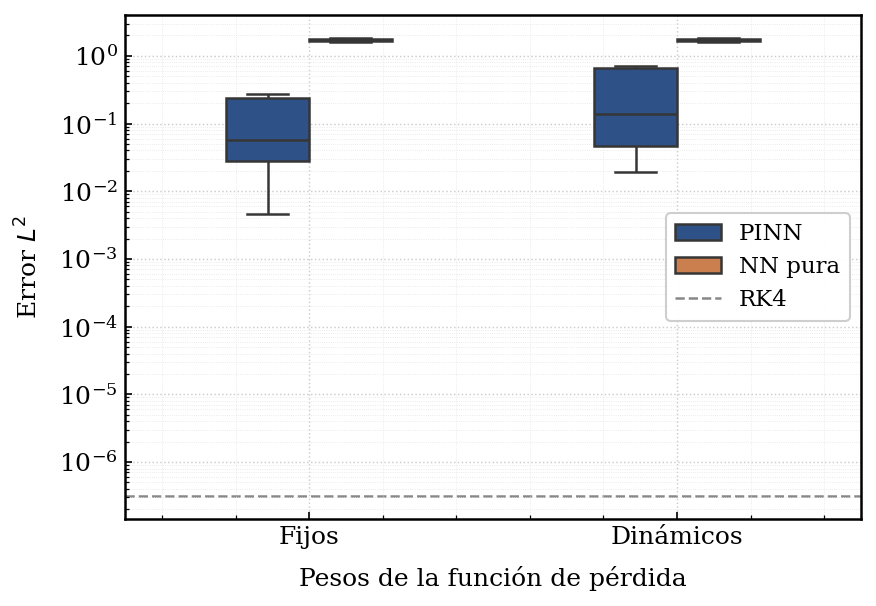

Fijos: PINN=1.8111e-01 ± 2.4130e-01 | NN=1.7228e+00 ± 7.2427e-02
Dinámicos: PINN=3.1139e-01 ± 3.2020e-01 | NN=1.7228e+00 ± 7.2427e-02
RK4: 3.1313e-07


In [38]:
mask_eje5 = (
    (df["num_domain_points"]  == BASE["num_domain_points"]) &
    (df["num_train_points"]   == BASE["num_train_points"]) &
    (df["train_region"]       == BASE["train_region"]) &
    (df["sampler"]            == BASE["sampler"]) &
    (df["optimizer"]          == BASE["optimizer"]) &
    (df["hidden_layers"]      == BASE["hidden_layers"]) &
    (df["lr"]                 == BASE["lr"])
)

df_eje5 = df[mask_eje5].copy()

# Fix: normalizar a string para que seaborn no se confunda con bool vs str
df_eje5["use_dynamic_weights"] = df_eje5["use_dynamic_weights"].astype(str).map(
    {"False": "Fijos", "True": "Dinámicos"}
)

df_eje5_long = df_eje5.melt(
    id_vars=["use_dynamic_weights"],
    value_vars=["error_l2_pinn", "error_l2_nn"],
    var_name="modelo", value_name="error_l2"
).replace({"error_l2_pinn": "PINN", "error_l2_nn": "NN pura"})

fig, ax = plt.subplots(figsize=(6, 4.2))

sns.boxplot(
    data=df_eje5_long, x="use_dynamic_weights", y="error_l2", hue="modelo",
    palette={"PINN": "#1f4e96", "NN pura": "#e07b39"},
    order=["Fijos", "Dinámicos"],
    width=0.45, linewidth=1.2, showfliers=False, ax=ax
)
ax.axhline(
    df_base["error_l2_rk4"].mean(),
    color="#888888", linewidth=1.2, linestyle="--", zorder=0, label="RK4"
)
handles, labels = ax.get_legend_handles_labels()
ax.legend(handles, labels, frameon=True, framealpha=0.95,
          edgecolor="#cccccc", fontsize=11, title=None)

ax.set_xlabel("Pesos de la función de pérdida", labelpad=8)
ax.set_ylabel("Error $L^2$", labelpad=8)
ax.set_yscale("log")
ax.grid(True, which="major", linestyle=":", linewidth=0.7, color="#cccccc", zorder=0)
ax.grid(True, which="minor", linestyle=":", linewidth=0.4, color="#e5e5e5", zorder=0)

plt.tight_layout()
plt.savefig(FIGS_DIR / "eje5_dynamic_weights.png", dpi=300, bbox_inches="tight")
plt.show()

for dw, grp in df[mask_eje5].groupby("use_dynamic_weights"):
    label = "Dinámicos" if dw else "Fijos"
    print(f"{label}: PINN={grp['error_l2_pinn'].mean():.4e} ± {grp['error_l2_pinn'].std():.4e} "
          f"| NN={grp['error_l2_nn'].mean():.4e} ± {grp['error_l2_nn'].std():.4e}")
print(f"RK4: {df_base['error_l2_rk4'].mean():.4e}")

## Eje 6: Tasa de aprendizaje

Se compara lr=0.001 (base) frente a lr=0.01,
manteniendo el resto de parámetros en su valor base.

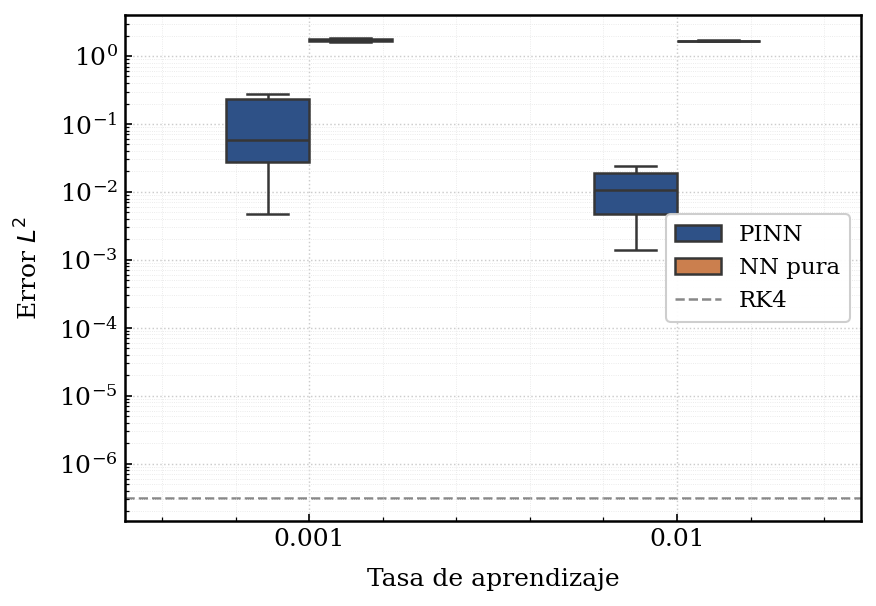

lr=0.001: PINN=1.8111e-01 ± 2.4130e-01 | NN=1.7228e+00 ± 7.2427e-02
lr=0.01: PINN=1.3356e-02 ± 1.2058e-02 | NN=1.6674e+00 ± 3.2628e-02
RK4: 3.1313e-07


In [40]:
mask_eje6 = (
    df["lr"].isin([0.001, 0.01]) &
    (df["num_domain_points"]   == BASE["num_domain_points"]) &
    (df["num_train_points"]    == BASE["num_train_points"]) &
    (df["train_region"]        == BASE["train_region"]) &
    (df["sampler"]             == BASE["sampler"]) &
    (df["use_dynamic_weights"] == BASE["use_dynamic_weights"]) &
    (df["optimizer"]           == BASE["optimizer"]) &
    (df["hidden_layers"]       == BASE["hidden_layers"])
)

df_eje6 = df[mask_eje6].copy()
df_eje6["lr"] = df_eje6["lr"].astype(str)

df_eje6_long = df_eje6.melt(
    id_vars=["lr"],
    value_vars=["error_l2_pinn", "error_l2_nn"],
    var_name="modelo", value_name="error_l2"
).replace({"error_l2_pinn": "PINN", "error_l2_nn": "NN pura"})

fig, ax = plt.subplots(figsize=(6, 4.2))

sns.boxplot(
    data=df_eje6_long, x="lr", y="error_l2", hue="modelo",
    palette={"PINN": "#1f4e96", "NN pura": "#e07b39"},
    order=["0.001", "0.01"],
    width=0.45, linewidth=1.2, showfliers=False, ax=ax
)
ax.axhline(
    df_base["error_l2_rk4"].mean(),
    color="#888888", linewidth=1.2, linestyle="--", zorder=0, label="RK4"
)
handles, labels = ax.get_legend_handles_labels()
ax.legend(handles, labels, frameon=True, framealpha=0.95,
          edgecolor="#cccccc", fontsize=11, title=None)

ax.set_xlabel("Tasa de aprendizaje", labelpad=8)
ax.set_ylabel("Error $L^2$", labelpad=8)
ax.set_yscale("log")
ax.grid(True, which="major", linestyle=":", linewidth=0.7, color="#cccccc", zorder=0)
ax.grid(True, which="minor", linestyle=":", linewidth=0.4, color="#e5e5e5", zorder=0)

plt.tight_layout()
plt.savefig(FIGS_DIR / "eje6_lr.png", dpi=300, bbox_inches="tight")
plt.show()

for lr_val, grp in df[mask_eje6].groupby("lr"):
    print(f"lr={lr_val}: PINN={grp['error_l2_pinn'].mean():.4e} ± {grp['error_l2_pinn'].std():.4e} "
          f"| NN={grp['error_l2_nn'].mean():.4e} ± {grp['error_l2_nn'].std():.4e}")
print(f"RK4: {df_base['error_l2_rk4'].mean():.4e}")

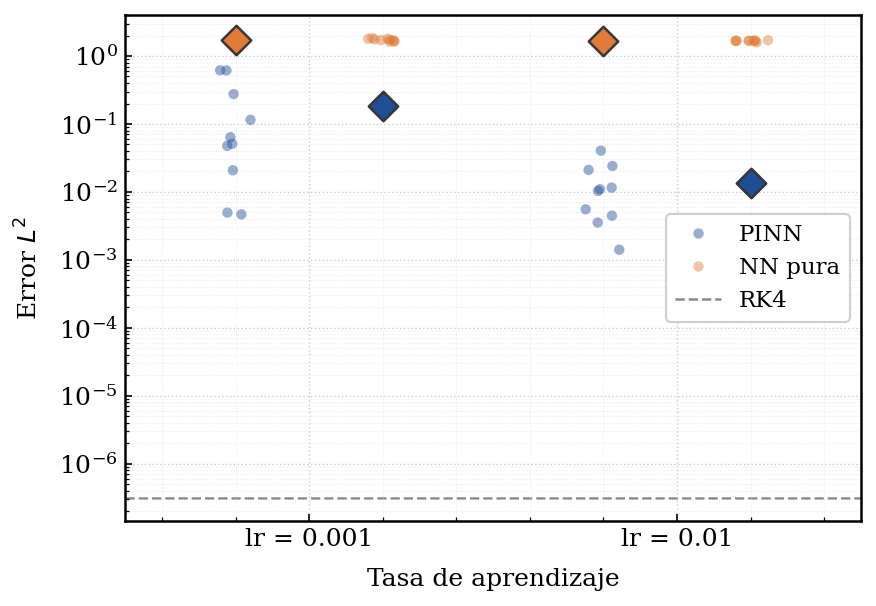

In [42]:
fig, ax = plt.subplots(figsize=(6, 4.2))

df_eje6_long["lr_label"] = df_eje6_long["lr"].map({"0.001": "lr = 0.001", "0.01": "lr = 0.01"})

# Puntos individuales (seeds)
sns.stripplot(
    data=df_eje6_long, x="lr_label", y="error_l2", hue="modelo",
    palette={"PINN": "#1f4e96", "NN pura": "#e07b39"},
    order=["lr = 0.001", "lr = 0.01"],
    dodge=True, size=5, alpha=0.45, jitter=True, ax=ax
)

# Medias como diamantes
means_eje6 = df_eje6_long.groupby(["lr_label", "modelo"])["error_l2"].mean().reset_index()
sns.stripplot(
    data=means_eje6, x="lr_label", y="error_l2", hue="modelo",
    palette={"PINN": "#1f4e96", "NN pura": "#e07b39"},
    order=["lr = 0.001", "lr = 0.01"],
    dodge=True, size=10, marker="D", jitter=0.05,
    linewidth=1.2, ax=ax, legend=False
)

ax.axhline(
    df_base["error_l2_rk4"].mean(),
    color="#888888", linewidth=1.2, linestyle="--", zorder=0, label="RK4"
)

# Leyenda sin duplicados
handles, labels = ax.get_legend_handles_labels()
seen = set()
h, l = [], []
for handle, label in zip(handles, labels):
    if label not in seen:
        seen.add(label)
        h.append(handle)
        l.append(label)
ax.legend(h, l, frameon=True, framealpha=0.95,
          edgecolor="#cccccc", fontsize=11, title=None)

ax.set_xlabel("Tasa de aprendizaje", labelpad=8)
ax.set_ylabel("Error $L^2$", labelpad=8)
ax.set_yscale("log")
ax.grid(True, which="major", linestyle=":", linewidth=0.7, color="#cccccc", zorder=0)
ax.grid(True, which="minor", linestyle=":", linewidth=0.4, color="#e5e5e5", zorder=0)

plt.tight_layout()
plt.savefig(FIGS_DIR / "eje6_lr_strip.png", dpi=300, bbox_inches="tight")
plt.show()

## Ejes 7, 8 y 9: Datos de entrenamiento

Se analiza el impacto del número de puntos de entrenamiento y 
de la región del dominio donde se proporcionan los datos.

- **Eje 7**: número de puntos (3, 5, 10, 15, 30) con región 20%
- **Eje 8**: región (20% vs 50%) con 15 puntos
- **Eje 9**: cruce puntos × región al 50%

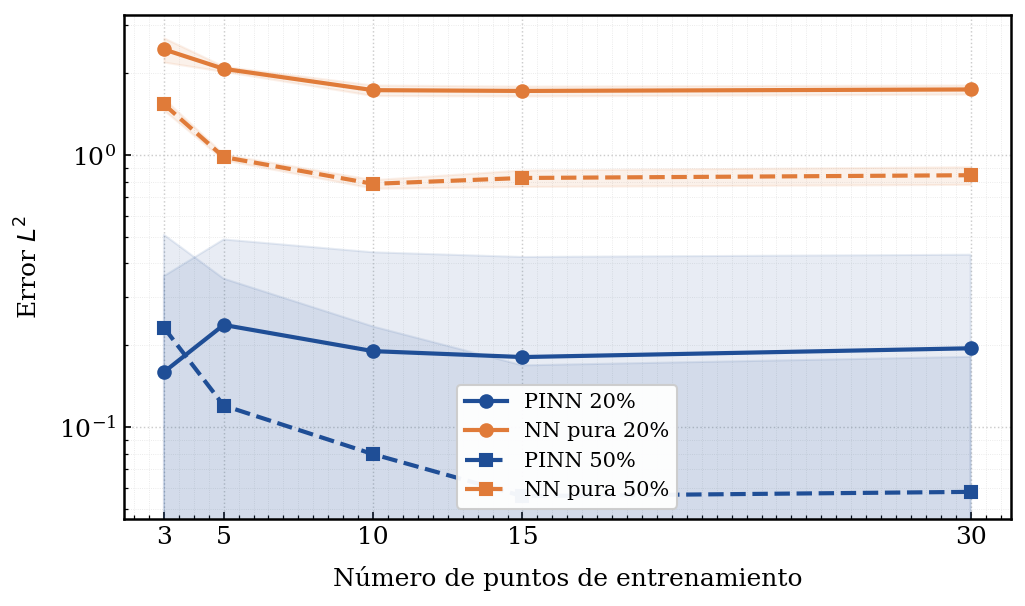

In [44]:
# ── Eje 7: puntos de entrenamiento con región 20% ─────────────────────
mask_eje7 = (
    (df["train_region"]        == 0.2) &
    (df["num_domain_points"]   == BASE["num_domain_points"]) &
    (df["sampler"]             == BASE["sampler"]) &
    (df["use_dynamic_weights"] == BASE["use_dynamic_weights"]) &
    (df["optimizer"]           == BASE["optimizer"]) &
    (df["hidden_layers"]       == BASE["hidden_layers"]) &
    (df["lr"]                  == BASE["lr"])
)
df_eje7 = df[mask_eje7].groupby("num_train_points")["error_l2_pinn"].agg(
    media="mean", std="std"
).reset_index()

# ── Eje 9: cruce puntos × región 50% ──────────────────────────────────
mask_eje9 = (
    (df["train_region"]        == 0.5) &
    (df["num_domain_points"]   == BASE["num_domain_points"]) &
    (df["sampler"]             == BASE["sampler"]) &
    (df["use_dynamic_weights"] == BASE["use_dynamic_weights"]) &
    (df["optimizer"]           == BASE["optimizer"]) &
    (df["hidden_layers"]       == BASE["hidden_layers"]) &
    (df["lr"]                  == BASE["lr"])
)
for mask, label_region, color_pinn, color_nn, ls in [
    (mask_eje7, "20%", "#1f4e96", "#e07b39", "-"),
    (mask_eje9, "50%", "#1f4e96", "#e07b39", "--"),
]:
    pass  # solo para mostrar la lógica; código abajo

df_eje7_full = df[mask_eje7].groupby("num_train_points")[
    ["error_l2_pinn", "error_l2_nn"]
].agg(["mean", "std"]).reset_index()

df_eje9_full = df[mask_eje9].groupby("num_train_points")[
    ["error_l2_pinn", "error_l2_nn"]
].agg(["mean", "std"]).reset_index()

fig, ax = plt.subplots(figsize=(7, 4.2))

for df_e, ls, marker, region in [
    (df_eje7_full, "-",  "o", "20%"),
    (df_eje9_full, "--", "s", "50%"),
]:
    x      = df_e["num_train_points"].values
    yp     = df_e["error_l2_pinn"]["mean"].values
    sp     = df_e["error_l2_pinn"]["std"].values
    yn     = df_e["error_l2_nn"]["mean"].values
    sn     = df_e["error_l2_nn"]["std"].values

    ax.plot(x, yp, marker+ls, color="#1f4e96", linewidth=2,
            markersize=6, label=f"PINN {region}", zorder=3)
    ax.fill_between(x, yp-sp, yp+sp, color="#1f4e96", alpha=0.10, zorder=2)

    ax.plot(x, yn, marker+ls, color="#e07b39", linewidth=2,
            markersize=6, label=f"NN pura {region}", zorder=3)
    ax.fill_between(x, yn-sn, yn+sn, color="#e07b39", alpha=0.10, zorder=2)

ax.set_xlabel("Número de puntos de entrenamiento", labelpad=8)
ax.set_ylabel("Error $L^2$", labelpad=8)
ax.set_yscale("log")
ax.set_xticks([3, 5, 10, 15, 30])
ax.get_xaxis().set_major_formatter(mpl.ticker.ScalarFormatter())
ax.legend(frameon=True, framealpha=0.95, edgecolor="#cccccc", fontsize=10)
ax.grid(True, which="major", linestyle=":", linewidth=0.7, color="#cccccc")
ax.grid(True, which="minor", linestyle=":", linewidth=0.4, color="#e5e5e5")

plt.tight_layout()
plt.savefig(FIGS_DIR / "eje7_9_v1_lineas.png", dpi=300, bbox_inches="tight")
plt.show()

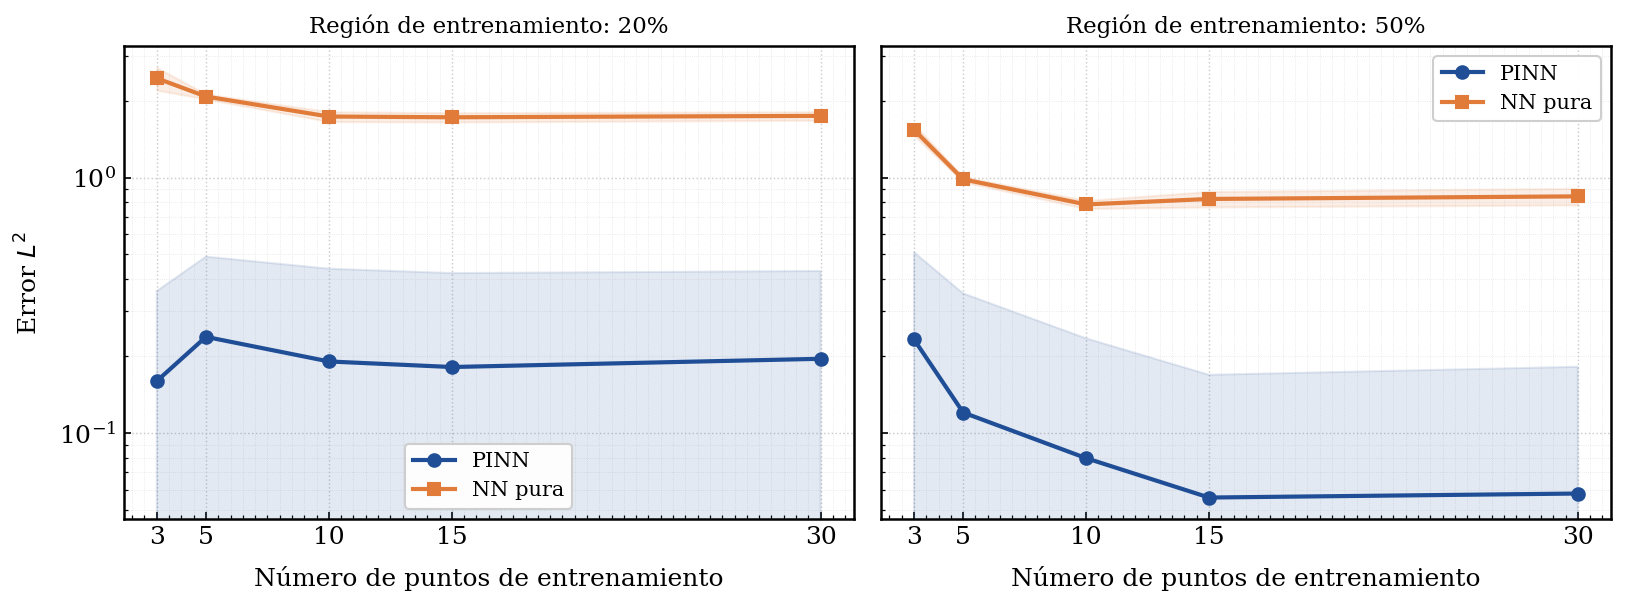

In [46]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4.2), sharey=True)

for ax, df_e, region in zip(axes, [df_eje7_full, df_eje9_full], ["20%", "50%"]):
    x  = df_e["num_train_points"].values
    yp = df_e["error_l2_pinn"]["mean"].values
    sp = df_e["error_l2_pinn"]["std"].values
    yn = df_e["error_l2_nn"]["mean"].values
    sn = df_e["error_l2_nn"]["std"].values

    ax.plot(x, yp, "o-", color="#1f4e96", linewidth=2, markersize=6,
            label="PINN", zorder=3)
    ax.fill_between(x, yp-sp, yp+sp, color="#1f4e96", alpha=0.12, zorder=2)

    ax.plot(x, yn, "s-", color="#e07b39", linewidth=2, markersize=6,
            label="NN pura", zorder=3)
    ax.fill_between(x, yn-sn, yn+sn, color="#e07b39", alpha=0.12, zorder=2)


    ax.set_title(f"Región de entrenamiento: {region}", fontsize=11)
    ax.set_xlabel("Número de puntos de entrenamiento", labelpad=8)
    ax.set_yscale("log")
    ax.set_xticks([3, 5, 10, 15, 30])
    ax.get_xaxis().set_major_formatter(mpl.ticker.ScalarFormatter())
    ax.legend(frameon=True, framealpha=0.95, edgecolor="#cccccc", fontsize=10)
    ax.grid(True, which="major", linestyle=":", linewidth=0.7, color="#cccccc")
    ax.grid(True, which="minor", linestyle=":", linewidth=0.4, color="#e5e5e5")

axes[0].set_ylabel("Error $L^2$", labelpad=8)
plt.tight_layout()
plt.savefig(FIGS_DIR / "eje7_9_v2_subplots.png", dpi=300, bbox_inches="tight")
plt.show()

## Resumen de resultados

Tabla resumen con la media y desviación típica del error L2 de la PINN 
para cada eje de variación, junto con la configuración base como referencia.

In [48]:
resumen = []

# ── BASE ──────────────────────────────────────────────────────────────────
resumen.append({
    "Eje":           "BASE",
    "Configuración": "—",
    "PINN media":    df_base["error_l2_pinn"].mean(),
    "PINN std":      df_base["error_l2_pinn"].std(),
    "NN media":      df_base["error_l2_nn"].mean(),
    "NN std":        df_base["error_l2_nn"].std(),
    "RK4 media":     df_base["error_l2_rk4"].mean(),
    "N":             len(df_base),
})

# ── Ejes ──────────────────────────────────────────────────────────────────
ejes = [
    ("Eje 1 · Puntos colocación", "num_domain_points", mask_eje1),
    ("Eje 2 · Sampler",           "sampler",           mask_eje2),
    ("Eje 3 · Optimizador",       "optimizer",         mask_eje3),
    ("Eje 4 · Arquitectura",      "hidden_layers",     mask_eje4),
    ("Eje 5 · Pesos dinámicos",   "use_dynamic_weights", mask_eje5.index if hasattr(mask_eje5, 'index') else mask_eje5),
    ("Eje 6 · Learning rate",     "lr",                mask_eje6),
    ("Eje 7 · Puntos train 20%",  "num_train_points",  mask_eje7),
    ("Eje 9 · Puntos train 50%",  "num_train_points",  mask_eje9),
]

for eje_label, col, mask in ejes:
    grp = df[mask] if not isinstance(mask, pd.Index) else df.loc[mask]
    for val, subgrp in grp.groupby(col):
        resumen.append({
            "Eje":           eje_label,
            "Configuración": str(val),
            "PINN media":    subgrp["error_l2_pinn"].mean(),
            "PINN std":      subgrp["error_l2_pinn"].std(),
            "NN media":      subgrp["error_l2_nn"].mean(),
            "NN std":        subgrp["error_l2_nn"].std(),
            "RK4 media":     df_base["error_l2_rk4"].mean(),
            "N":             len(subgrp),
        })

df_resumen = pd.DataFrame(resumen)

# ── Formatear ─────────────────────────────────────────────────────────────
for col in ["PINN media", "PINN std", "NN media", "NN std", "RK4 media"]:
    df_resumen[col] = df_resumen[col].apply(lambda x: f"{x:.3e}")

# ── Display ───────────────────────────────────────────────────────────────
pd.set_option("display.max_rows", 100)
pd.set_option("display.max_columns", 10)
pd.set_option("display.width", 120)

print(f"\n{'═'*110}")
print(f"{'EJE':<28} {'CONFIG':<18} {'PINN media':>12} {'PINN std':>12} "
      f"{'NN media':>12} {'NN std':>12} {'RK4 media':>12} {'N':>4}")
print(f"{'─'*110}")

eje_actual = None
for _, row in df_resumen.iterrows():
    if row["Eje"] != eje_actual:
        if eje_actual is not None:
            print(f"{'─'*110}")
        eje_actual = row["Eje"]
    print(f"{row['Eje']:<28} {row['Configuración']:<18} "
          f"{row['PINN media']:>12} {row['PINN std']:>12} "
          f"{row['NN media']:>12} {row['NN std']:>12} "
          f"{row['RK4 media']:>12} {row['N']:>4}")

print(f"{'═'*110}")


══════════════════════════════════════════════════════════════════════════════════════════════════════════════
EJE                          CONFIG               PINN media     PINN std     NN media       NN std    RK4 media    N
──────────────────────────────────────────────────────────────────────────────────────────────────────────────
BASE                         —                     1.811e-01    2.413e-01    1.723e+00    7.243e-02    3.131e-07   10
──────────────────────────────────────────────────────────────────────────────────────────────────────────────
Eje 1 · Puntos colocación    50                    2.787e-01    3.262e-01    1.723e+00    7.243e-02    3.131e-07   10
Eje 1 · Puntos colocación    100                   1.834e-01    2.387e-01    1.723e+00    7.243e-02    3.131e-07   10
Eje 1 · Puntos colocación    250                   1.792e-01    2.464e-01    1.723e+00    7.243e-02    3.131e-07   10
Eje 1 · Puntos colocación    500                   1.811e-01    2.413e-01   